In [1]:
# --- 0. MASTER CONFIG & CLEANING ---
# This block is necessary to make sure all the other code blocks run properly. It does a basic cleanup of the raw input data.

sovi_vars = [
    "QPOVTY", "QCVLUN", "QED12LES", "QFHH", "QESL", "QAGEDEP", "QFEMALE",
    "QFEMLBR", "QRICH", "QSERV", "QEXTRCT", "QMOHO", "QNOAUTO",
    "QUNOCCHU", "MDGRENT", "MDHSEVAL", "PPUNIT", "QRENTER", "QSSBEN", "QHSEBRDN",
    "MEDAGE", "PERCAP", "QBLACK", "QASIAN", "QHISP", "QFAM", "QNOHLTH"
]

def apply_purge(dataframe, var_list):
    """Standardized cleaning to fix -999s and negative artifacts across all blocks"""
    d = dataframe.copy()
    # Fix placeholders
    d = d.replace([-999, -999.0], np.nan)
    # Clip negative artifacts (the -0.0292 issue)
    for col in var_list:
        if col in d.columns:
            d.loc[d[col] < 0, col] = 0
    # Drop zero population
    d = d[d['Total_Pop'] > 0]
    return d

# Use this as the reference so sovi_vars never shrinks during testing
master_sovi_list = sovi_vars.copy()

In [2]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# This can replicate my original*, unscaled k-means results and compare them to properly scaled results. 
# Right now, none of the data is actually exported, and I'm only showing one year at a time.

# The rest of the code blocks are sequential attempts to improve the silhouette scores and explained variance of the scaled results, i.e., create
# more distinct and effective clusters.


# * The results will actually be slightly different because there were some problems in the original dataset due to user error. Some years pulled the
# wrong ACS tables. There are not any major issues in my original thesis results, just some inconsistencies that I've fixed since then. 


# --- 1. DATA PREP ---
year = 2010
raw_df = pd.read_csv(f'data/yearly_data/{year}.csv')

# Use global purge and copy master list
df = apply_purge(raw_df, sovi_vars)
current_vars = sovi_vars.copy()
df_vars = df[current_vars]

# Impute raw values (Clean of -999 noise)
data_imputed = KNNImputer(n_neighbors=5).fit_transform(df_vars)
data_scaled = StandardScaler().fit_transform(data_imputed)

# --- 2. TESTING LOOP ---
combined_results = []
# Pre-calculate TSS to keep the loop clean
tss_u = np.sum((data_imputed - np.mean(data_imputed, axis=0))**2)
tss_s = np.sum((data_scaled - np.mean(data_scaled, axis=0))**2)

for k in range(2, 11):
    # Unscaled Comparison
    km_u = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(data_imputed)
    sil_u = silhouette_score(data_imputed, km_u.labels_)
    ev_u = 1 - (km_u.inertia_ / tss_u)

    # Scaled (The Standard)
    km_s = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(data_scaled)
    sil_s = silhouette_score(data_scaled, km_s.labels_)
    ev_s = 1 - (km_s.inertia_ / tss_s)

    combined_results.append({
        'k': k, 
        'Unscaled_Sil': sil_u, 'Unscaled_EV': ev_u, 
        'Scaled_Sil': sil_s, 'Scaled_EV': ev_s
    })

print(f"--- K-Means Comparison: Year {year} ---")
print(pd.DataFrame(combined_results))

--- K-Means Comparison: Year 2010 ---
    k  Unscaled_Sil  Unscaled_EV  Scaled_Sil  Scaled_EV
0   2      0.726105     0.601651    0.144797   0.163767
1   3      0.576885     0.785356    0.198746   0.312629
2   4      0.567860     0.872804    0.207384   0.375667
3   5      0.558830     0.909512    0.156937   0.419137
4   6      0.558868     0.927963    0.155118   0.449003
5   7      0.514226     0.951330    0.125403   0.469296
6   8      0.506982     0.962351    0.123905   0.485979
7   9      0.505152     0.965340    0.104616   0.502777
8  10      0.491759     0.973157    0.098890   0.510892


In [3]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import mstats

# This version uses a combined method where PCA is first used to reduce the dimensions, then the clusters are created based on those factors.

# It also includes two data cleaning steps, winsorization and coefficient of variance filtering, meant to marginally increase silhouette score and EV.
    # These can be toggled on and off.


# --- 1. CONFIG & DATA PREP ---
year = 2010
run_cv = True       # Toggle CV filtering
run_winsor = True   # Toggle Winsorization
raw_df = pd.read_csv(f'data/yearly_data/{year}.csv')

df = apply_purge(raw_df, sovi_vars)
current_vars = sovi_vars.copy()
df_vars = df[current_vars].copy()

# --- 2. WINSORIZATION ---
if run_winsor:
    for col in current_vars:
        mask = df_vars[col].notnull()
        if mask.any():
            df_vars.loc[mask, col] = mstats.winsorize(df_vars.loc[mask, col], limits=[0.05, 0.05])
    print("Winsorization applied.")
else:
    print("Winsorization bypassed.")

# Imputation
data_imputed = KNNImputer(n_neighbors=5).fit_transform(df_vars)
df_imputed_raw = pd.DataFrame(data_imputed, columns=current_vars)

# --- 3. CV VARIABLE FILTERING ---
if run_cv:
    temp_scaled = StandardScaler().fit_transform(data_imputed)
    temp_km = KMeans(n_clusters=4, random_state=42, n_init='auto').fit(temp_scaled)
    c_means = df_imputed_raw.groupby(temp_km.labels_).mean()
    cv_scores = c_means.std() / df_imputed_raw.mean().abs()
    
    selected_vars = cv_scores[cv_scores > 0.10].index.tolist()
    print(f"Dropped via CV: {cv_scores[cv_scores <= 0.10].index.tolist()}")
else:
    selected_vars = current_vars
    print("CV filtering bypassed.")

# --- 4. PCA REDUCTION ---
data_final_scaled = StandardScaler().fit_transform(df_imputed_raw[selected_vars])
pca = PCA(n_components=4)
data_pca = pca.fit_transform(data_final_scaled)

print(f"Total Explained Variance (PCA): {np.sum(pca.explained_variance_ratio_):.2%}")

# --- 5. K-MEANS TESTING LOOP ---
testing_results = []
tss_pca = np.sum((data_pca - np.mean(data_pca, axis=0))**2)

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    labels = kmeans.fit_predict(data_pca)
    
    testing_results.append({
        'k': k,
        'Silhouette': silhouette_score(data_pca, labels),
        'EV_PCA': 1 - (kmeans.inertia_ / tss_pca)
    })

print("\nPCA-Based K-Means Results:")
print(pd.DataFrame(testing_results))

Winsorization applied.
Dropped via CV: ['QAGEDEP', 'QFEMALE', 'QFEMLBR', 'PPUNIT']
Total Explained Variance (PCA): 70.96%

PCA-Based K-Means Results:
    k  Silhouette    EV_PCA
0   2    0.276435  0.314438
1   3    0.357585  0.560845
2   4    0.377799  0.656992
3   5    0.315044  0.711219
4   6    0.315168  0.748010
5   7    0.311807  0.769860
6   8    0.260640  0.784857
7   9    0.253403  0.796405
8  10    0.257362  0.808204


In [4]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import mstats

# I noticed during all the other steps that the optimal number of clusters is usually quite low. I don't like using a low number of clusters
# because I feel it removes some of the explanatory power of using clusters. Using 3 essentially just splits everything into high, medium, and low
# vulnerability. This might be the most mathematically optimal solution, but it doesn't have as much qualitative meaning.

# My solution to address this mismatch was to first create a smaller number of "parent clusters" capture the basic structure of vulnerability across
# the data, and then create "sub clusters" based on those parents for greater detail. This lets me have, say, 6 clusters that have higher silhouette
# scores and explained variance than if I had simply done k-mean with k=6.


# --- 1. CONFIG & DATA PREP ---
year = 2010

run_cv = True       # Toggle CV filtering
run_winsor = True   # Toggle Winsorization
raw_df = pd.read_csv(f'data/yearly_data/{year}.csv')

df = apply_purge(raw_df, sovi_vars)
current_vars = sovi_vars.copy()
df_vars = df[current_vars].copy()

# --- 2. PREPROCESSING ---
if run_winsor:
    for col in current_vars:
        mask = df_vars[col].notnull()
        if mask.any():
            df_vars.loc[mask, col] = mstats.winsorize(df_vars.loc[mask, col], limits=[0.05, 0.05])

data_imputed = KNNImputer(n_neighbors=5).fit_transform(df_vars)
df_raw = pd.DataFrame(data_imputed, columns=current_vars)

if run_cv:
    temp_scaled = StandardScaler().fit_transform(data_imputed)
    km_cv = KMeans(n_clusters=4, random_state=42, n_init='auto').fit(temp_scaled)
    cv_scores = df_raw.groupby(km_cv.labels_).mean().std() / df_raw.mean().abs()
    selected_vars = cv_scores[cv_scores > 0.10].index.tolist()
    print(f"Variables dropped: {cv_scores[cv_scores <= 0.10].index.tolist()}\n")
else:
    selected_vars = current_vars

data_scaled = StandardScaler().fit_transform(df_raw[selected_vars])

# --- 3. PCA & PARENT CLUSTERING ---
# Define number of parent and sub clusters
parent_k, sub_k = 3, 2    
 
data_pca = PCA(n_components=4).fit_transform(data_scaled)
kmeans_parent = KMeans(n_clusters=parent_k, n_init='auto', random_state=42)
df['parent_cluster'] = kmeans_parent.fit_predict(data_pca)

ev_p = 1 - (kmeans_parent.inertia_ / np.sum((data_pca - np.mean(data_pca, axis=0))**2))
print(f"--- PARENT LEVEL (k={parent_k}) ---\nEV: {ev_p:.2%} | Silhouette: {silhouette_score(data_pca, df['parent_cluster']):.4f}\n")

# --- 4. SUB-PARENT CLUSTERING ---
df['sub_cluster'] = df['parent_cluster'].astype(str)
sub_results = []

for p_id in range(parent_k):
    mask = (df['parent_cluster'] == p_id)
    sub_data = data_pca[mask]
    
    if len(sub_data) >= sub_k:
        km_sub = KMeans(n_clusters=sub_k, n_init='auto', random_state=42)
        df.loc[mask, 'sub_cluster'] = [f"{p_id}-{s}" for s in km_sub.fit_predict(sub_data)]
        ev_s = 1 - (km_sub.inertia_ / np.sum((sub_data - np.mean(sub_data, axis=0))**2))
        sub_results.append({'Parent': p_id, 'Sub_EV': ev_s, 'N': len(sub_data)})

print("--- SUB-PARENT METRICS ---")
print(pd.DataFrame(sub_results))

Variables dropped: ['QAGEDEP', 'QFEMALE', 'QFEMLBR', 'PPUNIT']

--- PARENT LEVEL (k=3) ---
EV: 56.08% | Silhouette: 0.3576

--- SUB-PARENT METRICS ---
   Parent    Sub_EV    N
0       0  0.378722  423
1       1  0.312459  660
2       2  0.414230  398


In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import mstats

# This version calculates everything based on the entire pooled dataset from 2010 to 2019. It marginally improves silhouette and EV, but
# also has the added benefit of making comparisons over time more stable. 


# --- 1. CONFIG & POOLING ---
years = range(2010, 2020)
parent_k, sub_k = 3, 2
run_cv, run_winsor = True, True # Toggles

raw_list = []
for yr in years:
    path = f'data/yearly_data/{yr}.csv'
    if os.path.exists(path):
        temp = pd.read_csv(path)
        temp['Year'] = yr
        raw_list.append(temp)

# Purge and prep variables
pool_df = apply_purge(pd.concat(raw_list, ignore_index=True), sovi_vars)
current_vars = sovi_vars.copy()
df_vars = pool_df[current_vars].copy()

# --- 2. PREPROCESSING (TOGGLEABLE) ---
if run_winsor:
    for col in current_vars:
        mask = df_vars[col].notnull()
        if mask.any():
            df_vars.loc[mask, col] = mstats.winsorize(df_vars.loc[mask, col], limits=[0.05, 0.05])

data_imputed = KNNImputer(n_neighbors=5).fit_transform(df_vars)
df_raw = pd.DataFrame(data_imputed, columns=current_vars)

if run_cv:
    temp_scaled = StandardScaler().fit_transform(data_imputed)
    km_cv = KMeans(n_clusters=4, random_state=42, n_init='auto').fit(temp_scaled)
    cv_scores = df_raw.groupby(km_cv.labels_).mean().std() / df_raw.mean().abs()
    selected_vars = cv_scores[cv_scores > 0.11].index.tolist()
    print(f"Dropped: {cv_scores[cv_scores <= 0.11].index.tolist()}\n")
else:
    selected_vars = current_vars

data_scaled = StandardScaler().fit_transform(df_raw[selected_vars])

# --- 3. PCA & PARENT CLUSTERING ---
data_pca = PCA(n_components=4).fit_transform(data_scaled)
km_p = KMeans(n_clusters=parent_k, n_init='auto', random_state=42)
pool_df['parent_cluster'] = km_p.fit_predict(data_pca)

ev_p = 1 - (km_p.inertia_ / np.sum((data_pca - np.mean(data_pca, axis=0))**2))
sil_p = silhouette_score(data_pca, pool_df['parent_cluster'], sample_size=10000)

print(f"--- POOLED PARENT LEVEL ---\nEV: {ev_p:.2%} | Sil: {sil_p:.4f}\n")

# --- 4. SUB-PARENT CLUSTERING ---
pool_df['sub_cluster'] = pool_df['parent_cluster'].astype(str)
sub_results = []

for p_id in range(parent_k):
    mask = (pool_df['parent_cluster'] == p_id)
    sub_data = data_pca[mask]
    
    if len(sub_data) >= sub_k:
        km_s = KMeans(n_clusters=sub_k, n_init='auto', random_state=42)
        pool_df.loc[mask, 'sub_cluster'] = [f"{p_id}-{s}" for s in km_s.fit_predict(sub_data)]
        ev_s = 1 - (km_s.inertia_ / np.sum((sub_data - np.mean(sub_data, axis=0))**2))
        sub_results.append({'Parent': p_id, 'Sub_EV': ev_s, 'N': len(sub_data)})

print("--- POOLED SUB-PARENT METRICS ---")
print(pd.DataFrame(sub_results))

Dropped: ['QAGEDEP', 'QFEMALE', 'QFEMLBR', 'PPUNIT']

--- POOLED PARENT LEVEL ---
EV: 56.23% | Sil: 0.3653

--- POOLED SUB-PARENT METRICS ---
   Parent    Sub_EV     N
0       0  0.372043  4053
1       1  0.395402  3904
2       2  0.306444  6853


In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import mstats


# This version adds another toggle meant to improve the silhouette and EV, 3-sigma outlier removal. 
# So far, this is the version I've decided is "most optimal," but I want to test its correlation with actual SoVI scores.

# Other parent and sub-parent k values can provide interesting results as well, and should be tested.


# --- 1. CONFIG & DATA POOLING ---
years = range(2010, 2020)
parent_k, sub_k = 3, 2
run_winsor, run_cv, run_3sigma = True, True, True  # Toggles

raw_list = []
for yr in years:
    path = f'data/yearly_data/{yr}.csv'
    if os.path.exists(path):
        temp = pd.read_csv(path).assign(Year=yr)
        raw_list.append(temp)

pool_df = apply_purge(pd.concat(raw_list, ignore_index=True), sovi_vars)
current_vars = sovi_vars.copy()
df_vars = pool_df[current_vars].copy()

# --- 2. PREPROCESSING ---
if run_winsor:
    for col in current_vars:
        mask = df_vars[col].notnull()
        if mask.any():
            df_vars.loc[mask, col] = mstats.winsorize(df_vars.loc[mask, col], limits=[0.05, 0.05])

data_imputed = KNNImputer(n_neighbors=5).fit_transform(df_vars)
df_raw = pd.DataFrame(data_imputed, columns=current_vars)

if run_cv:
    temp_scaled = StandardScaler().fit_transform(data_imputed)
    km_cv = KMeans(n_clusters=4, random_state=42, n_init='auto').fit(temp_scaled)
    cv_scores = df_raw.groupby(km_cv.labels_).mean().std() / df_raw.mean().abs()
    selected_vars = cv_scores[cv_scores > 0.11].index.tolist()
    print(f"Variables dropped: {cv_scores[cv_scores <= 0.11].index.tolist()}")
else:
    selected_vars = current_vars

data_scaled = StandardScaler().fit_transform(df_raw[selected_vars])
data_pca_raw = PCA(n_components=4).fit_transform(data_scaled)

# --- 3. 3-SIGMA OUTLIER REMOVAL (TOGGLEABLE) ---
if run_3sigma:
    outlier_mask = (np.abs(data_pca_raw - np.mean(data_pca_raw, axis=0)) > (3 * np.std(data_pca_raw, axis=0))).any(axis=1)
    pool_df_clean = pool_df[~outlier_mask].copy()
    data_pca = data_pca_raw[~outlier_mask]
    print(f"Removed {outlier_mask.sum()} outliers ({outlier_mask.mean():.2%})\n")
else:
    pool_df_clean = pool_df.copy()
    data_pca = data_pca_raw
    print("3-Sigma outlier removal bypassed.\n")

# --- 4. HIERARCHICAL CLUSTERING ---
km_p = KMeans(n_clusters=parent_k, n_init='auto', random_state=42)
pool_df_clean['parent_cluster'] = km_p.fit_predict(data_pca)

ev_p = 1 - (km_p.inertia_ / np.sum((data_pca - np.mean(data_pca, axis=0))**2))
sil_p = silhouette_score(data_pca, pool_df_clean['parent_cluster'], sample_size=10000)

print(f"--- POOLED PARENT LEVEL ---\nEV: {ev_p:.2%} | Sil: {sil_p:.4f}\n")

# --- 5. SUB-PARENT LEVEL ---
pool_df_clean['sub_cluster'] = pool_df_clean['parent_cluster'].astype(str)
sub_results = []

for p_id in range(parent_k):
    mask = (pool_df_clean['parent_cluster'] == p_id)
    sub_data = data_pca[mask]
    
    if len(sub_data) >= sub_k:
        km_s = KMeans(n_clusters=sub_k, n_init='auto', random_state=42)
        pool_df_clean.loc[mask, 'sub_cluster'] = [f"{p_id}-{s}" for s in km_s.fit_predict(sub_data)]
        ev_s = 1 - (km_s.inertia_ / np.sum((sub_data - np.mean(sub_data, axis=0))**2))
        sub_results.append({'Parent': p_id, 'Sub_EV': ev_s, 'N': len(sub_data)})

print("--- POOLED SUB-PARENT METRICS ---")
print(pd.DataFrame(sub_results))

Variables dropped: ['QAGEDEP', 'QFEMALE', 'QFEMLBR', 'PPUNIT']
Removed 233 outliers (1.57%)

--- POOLED PARENT LEVEL ---
EV: 57.28% | Sil: 0.3672

--- POOLED SUB-PARENT METRICS ---
   Parent    Sub_EV     N
0       0  0.305533  6833
1       1  0.377742  4042
2       2  0.389904  3702


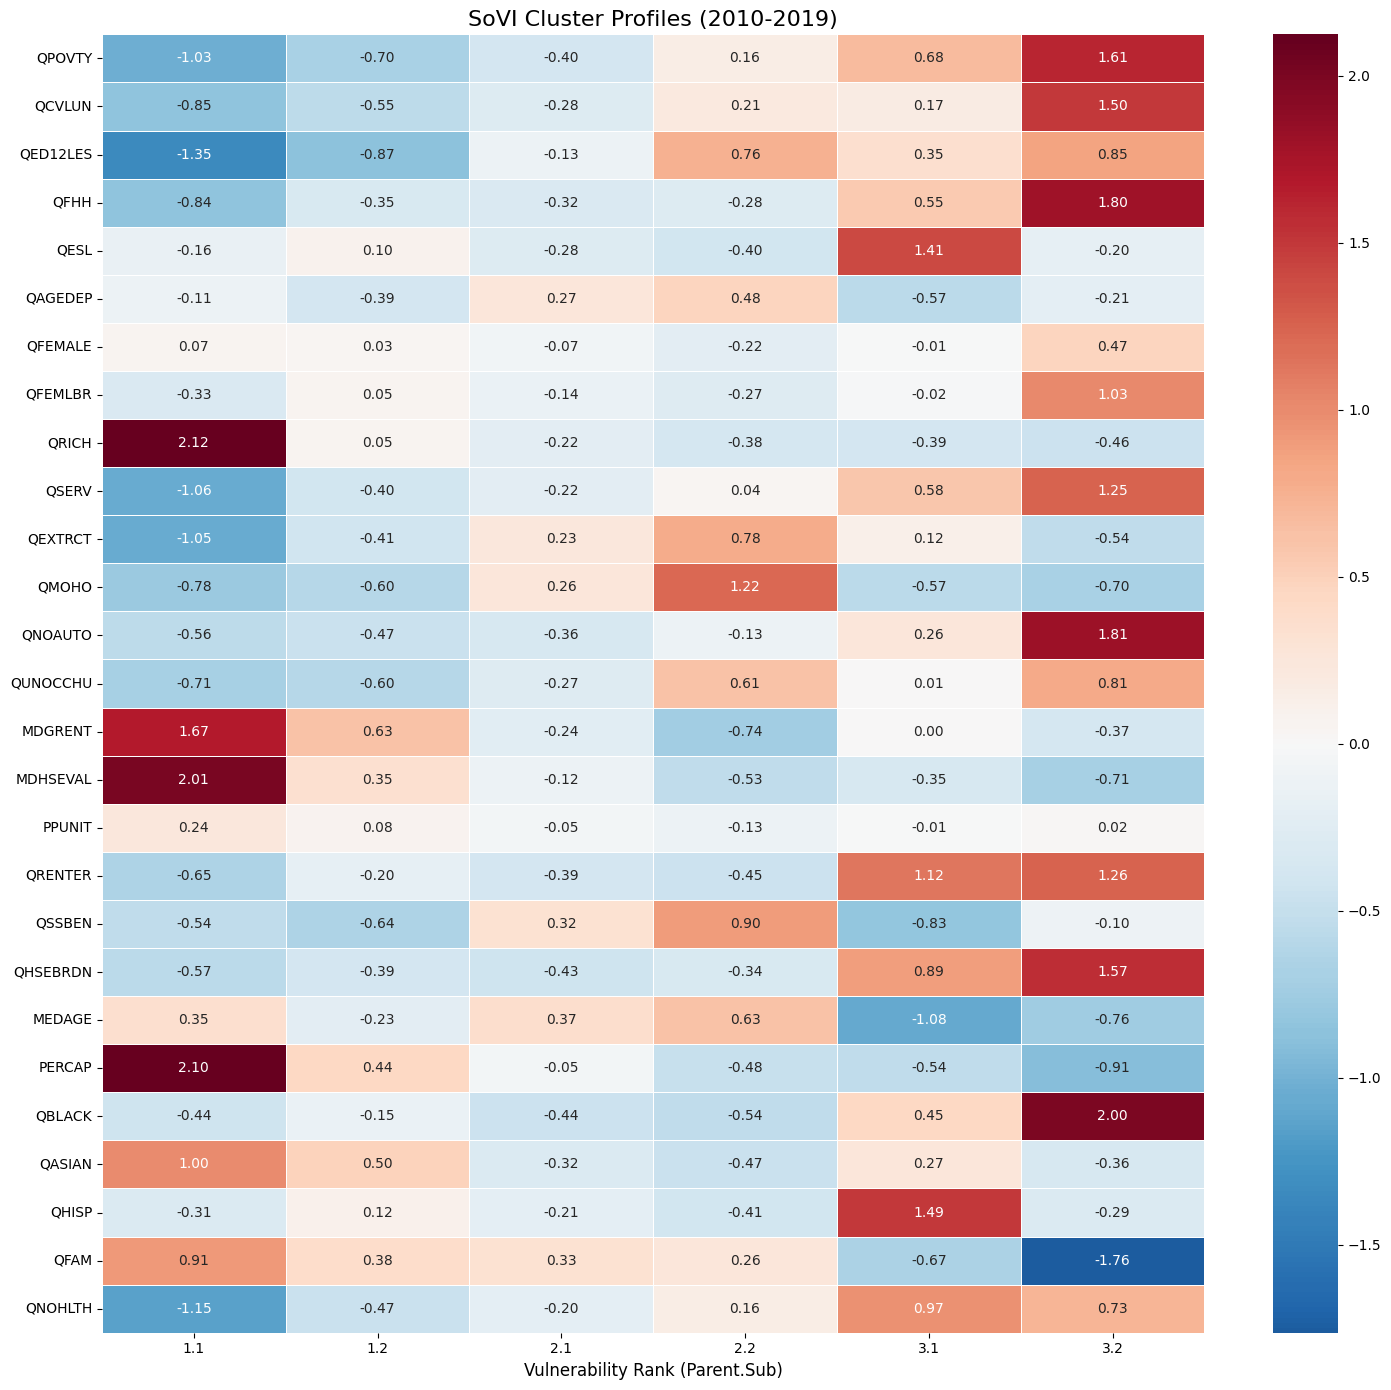

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# This version finalizes everything I have so far by sorting the clusters from low to high vulnerability. This is based on just their poverty rate,
# meaning there may be more elegant or rigorous ways to do this. 

# It also maps the variables as z-scores for quick comparison between the clusters. Additionally, variables that were dropped based on the CV filter
# are added back in so that they can be included in profile analysis. They were removed from the clustering process in order to create more well-defined
# clusters, but are still present in the overall database.


# --- 1. RANK PARENT CLUSTERS ---
# Find parent order by mean poverty
p_rank_idx = pool_df_clean.groupby('parent_cluster')['QPOVTY'].mean().sort_values().index
p_map = {old: i + 1 for i, old in enumerate(p_rank_idx)}

# --- 2. RANK SUB-CLUSTERS WITHIN PARENTS ---
rank_map = {}
for p_old, p_new in p_map.items():
    # Get sub-clusters belonging to this parent
    subs = pool_df_clean[pool_df_clean['parent_cluster'] == p_old]['sub_cluster'].unique()
    
    # Sort these specific sub-clusters by poverty
    s_rank_idx = pool_df_clean[pool_df_clean['sub_cluster'].isin(subs)].groupby('sub_cluster')['QPOVTY'].mean().sort_values().index
    
    # Create label: "ParentRank.SubRank" (e.g., 1.1, 1.2)
    for i, s_old in enumerate(s_rank_idx):
        rank_map[s_old] = f"{p_new}.{i+1}"

# --- 3. APPLY TO DATAFRAME ---
final_df = pool_df_clean.copy()
final_df['vulnerability_rank'] = final_df['sub_cluster'].map(rank_map)

# --- 4. PREP HEATMAP DATA (SWITCHED TO ALL VARIABLES) ---
profiles = final_df.groupby('vulnerability_rank')[current_vars].mean()

# Standardize to Z-Scores using the full variable list
z_profiles = (profiles - final_df[current_vars].mean()) / final_df[current_vars].std()

# Ensure the index sorts numerically (1.1, 1.2, 2.1)
z_profiles.index = pd.to_numeric(z_profiles.index)
z_profiles = z_profiles.sort_index()

# --- 5. PLOTTING ---
plt.figure(figsize=(15, 14)) # Slightly taller to accommodate more variables
sns.heatmap(z_profiles.T, 
            cmap='RdBu_r', 
            center=0, 
            annot=True, 
            fmt=".2f", 
            linewidths=.5)

plt.title(f"SoVI Cluster Profiles ({years.start}-{years.stop-1})", fontsize=16)
plt.xlabel("Vulnerability Rank (Parent.Sub)", fontsize=12)
plt.tight_layout()
plt.show()


--- Multicollinearity Test ---
    Variable        VIF
17    PERCAP  12.785364
5      QRICH   5.691247
12  MDHSEVAL   5.269681
0     QPOVTY   5.256383
13   QRENTER   4.271517
4       QESL   4.058887
2   QED12LES   4.001127
3       QFHH   3.925163
16    MEDAGE   3.818665
18    QBLACK   3.800372
21      QFAM   3.580909
14    QSSBEN   3.484425
9    QNOAUTO   3.459126
20     QHISP   3.425292
15  QHSEBRDN   3.285385
11   MDGRENT   2.975394
8      QMOHO   2.815560
22   QNOHLTH   2.486059
1     QCVLUN   2.075379
7    QEXTRCT   1.988601
6      QSERV   1.952204
19    QASIAN   1.784023
10  QUNOCCHU   1.644720


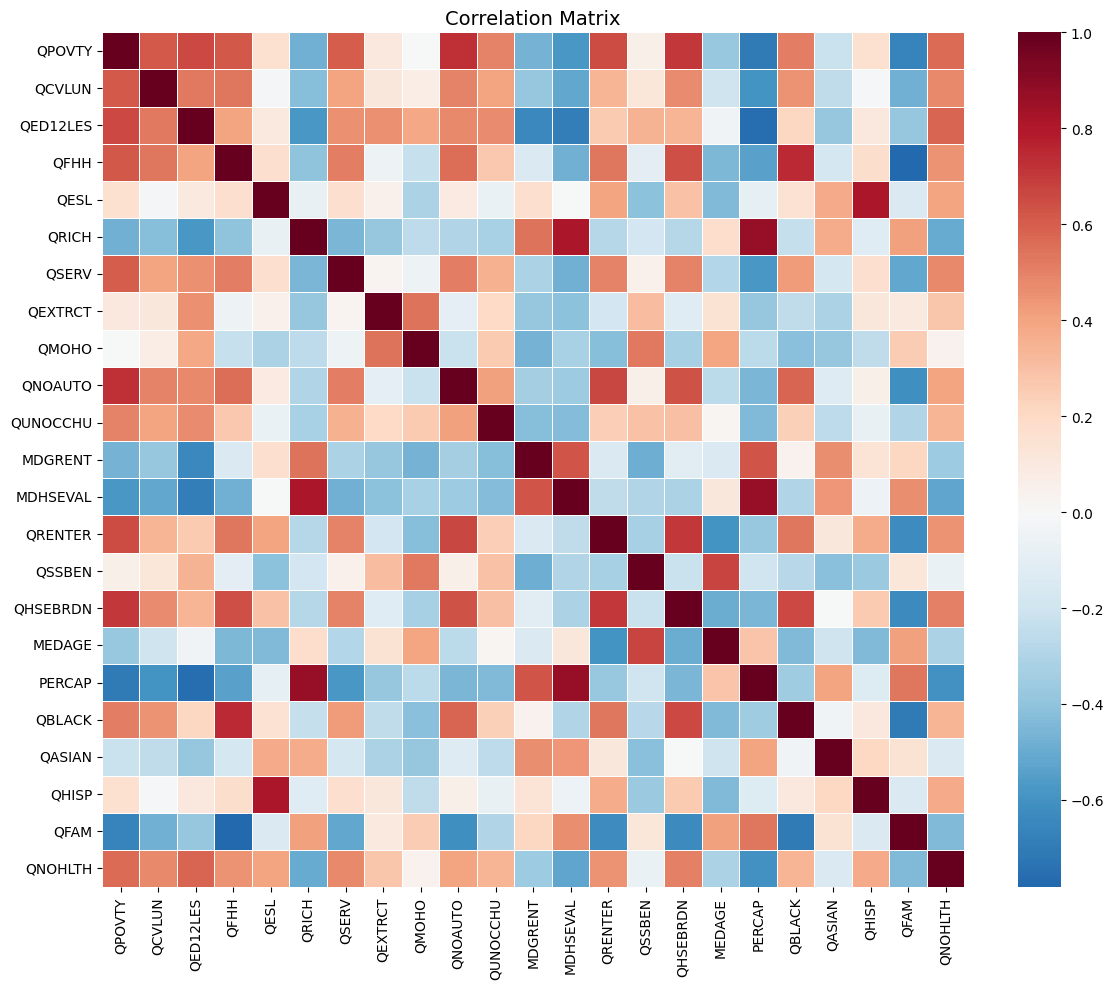

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Finally, for now, this block just checks for multicollinearity and shows the correlation matrix.


# --- 1. PREP SCALED DATA ---
X_vif = pd.DataFrame(data_scaled, columns=selected_vars)

# --- 2. CALCULATE VIF ---
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

# Sort results
vif_data = vif_data.sort_values(by="VIF", ascending=False)

print("--- Multicollinearity Test ---")
print(vif_data)

# --- 3. CORRELATION HEATMAP ---
plt.figure(figsize=(12, 10))
sns.heatmap(X_vif.corr(), 
            annot=False, 
            fmt=".2f", 
            cmap='RdBu_r', 
            center=0, 
            linewidths=.5)

plt.title("Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()